In [1]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# 1. 初期パラメータ設定 (Experiment Configurations)
# =====================================================================
# [モデル設定]
N = 40                  # 変数の数 (観測の数 P も今回は同じ40)
F = 10.0                # 強制項
dt = 0.01               # 積分時間ステップ
sampling_dt = 0.05      # 観測・同化の間隔 (6時間相当: 0.25日/5日)
m = 8                   # アンサンブルメンバー数
p = 40                  # 観測点の数 (今回は全点観測なので N と同じ)

# [時間設定]
years = 2
units_per_year = 73.0   # 1年 = 365日 / 5日 = 73ユニット
total_time = years * units_per_year
spin_up_time = units_per_year

steps_total = int(total_time / dt)
steps_spin_up = int(spin_up_time / dt)
sampling_interval = int(sampling_dt / dt)

# [データ同化設定]
H_mat = np.eye(N)                       # 観測演算子 H (全点観測)
R_mat = np.eye(N)                       # 観測誤差共分散 R (対角成分1)

# =====================================================================
# 2. Nature Run (真値) と Observation (観測) の生成
# =====================================================================
def lorenz96(x, F):
    return (np.roll(x, -1, axis=0) - np.roll(x, 2, axis=0)) * np.roll(x, 1, axis=0) - x + F

def M(x_in, dt, steps):
    x_out = x_in.copy()
    for _ in range(steps):
        k1 = lorenz96(x_out, F)
        k2 = lorenz96(x_out + k1 * (dt / 2.0), F)
        k3 = lorenz96(x_out + k2 * (dt / 2.0), F)
        k4 = lorenz96(x_out + k3 * dt, F)
        x_out += (k1 + 2.0*k2 + 2.0*k3 + k4) * (dt / 6.0)
    return x_out

print("Nature Runと観測データを生成中...")
x = np.full(N, F)
x[19] += 1.001

true_states = []
for s in range(steps_total):
    x = M(x, dt, 1)
    if s >= steps_spin_up and (s - steps_spin_up) % sampling_interval == 0:
        true_states.append(x.copy())
true_states = np.array(true_states)

rng_obs = np.random.default_rng(seed=67) 
noise = rng_obs.normal(loc=0.0, scale=1.0, size=true_states.shape)
noise -= np.mean(noise, axis=0)
y_o_data_full = true_states + noise

num_cycles = y_o_data_full.shape[0]

print("生成完了！")

Nature Runと観測データを生成中...
生成完了！


In [2]:
# =====================================================================
# 3. LETKF + RTPP / RTPS 完成版
# =====================================================================


def symmetric_sqrt(A, eig_floor=1.0e-12):
    """
    対称行列 A の対称平方根 A^{1/2} を返す。
    数値誤差で非有限値や分解失敗が出た場合は、
    対称化と微小ジッターを入れてフォールバックする。
    """
    A = np.asarray(A, dtype=float)
    A = 0.5 * (A + A.T)
    A = np.nan_to_num(A, nan=0.0, posinf=0.0, neginf=0.0)
    A = A + eig_floor * np.eye(A.shape[0])

    try:
        eigvals, eigvecs = np.linalg.eigh(A)
        eigvals = np.maximum(eigvals, eig_floor)
        return eigvecs @ np.diag(np.sqrt(eigvals)) @ eigvecs.T
    except np.linalg.LinAlgError:
        u, s, vt = np.linalg.svd(A, full_matrices=False)
        s = np.maximum(s, eig_floor)
        return u @ np.diag(np.sqrt(s)) @ vt



def make_H(obs_indices, N):
    """
    観測点 obs_indices に対応する線形観測演算子 H を作る。
    全点観測なら obs_indices = np.arange(N)。
    """
    obs_indices = np.asarray(obs_indices, dtype=int)
    H = np.zeros((len(obs_indices), N))
    for k, j in enumerate(obs_indices):
        H[k, j] = 1.0
    return H



def gaspari_like_weight(distance, sigma):
    """
    元のノートの R_localization_inv に合わせた簡易ガウス型局所化。
    距離がしきい値より大きい観測は重み0。
    """
    cutoff = np.sqrt(10.0 / 3.0) * sigma * 2.0
    if distance < cutoff:
        return np.exp(-(distance**2) / (2.0 * sigma**2))
    return 0.0



def localization_weights_for_grid(i, obs_indices, sigma, N):
    """
    状態変数 i の解析に使う観測局所化重みを返す。
    戻り値 shape: (p_obs,)
    """
    weights = np.zeros(len(obs_indices))
    for k, j in enumerate(obs_indices):
        d = min(abs(i - j), N - abs(i - j))
        weights[k] = gaspari_like_weight(d, sigma)
    return weights



def letkf_analysis(
    X_b,
    y_o,
    H,
    R,
    obs_indices,
    sigma,
    inflation=1.0,
    method="none",
    alpha=0.0,
    eps=1.0e-12,
):
    """
    1同化サイクル分の LETKF 解析を行う。

    method:
        "none" : 通常LETKF
        "rtpp" : RTPP LETKF
        "rtps" : RTPS LETKF

    使用する主な式:

    xb_mean = mean(X_b)
    dX_b    = X_b - xb_mean

    yb_mean = mean(H X_b)
    dY_b    = H X_b - yb_mean
    innov   = y_o - yb_mean

    P_a_tilde =
        [ (m-1)/Delta I + dY_b^T R^{-1}_loc dY_b ]^{-1}

    w =
        P_a_tilde dY_b^T R^{-1}_loc innov

    xa_mean_i =
        xb_mean_i + dX_b_i w

    W =
        [ (m-1) P_a_tilde ]^{1/2}

    dXa_base_i =
        dX_b_i W

    RTPP:
        dXa_i = (1-alpha) dXa_base_i + alpha sqrt(Delta) dX_b_i

    RTPS:
        r_i = 1 - alpha + alpha sqrt(Delta) sigma_b_i / sigma_a_i
        dXa_i = r_i dXa_base_i
    """
    N, m = X_b.shape
    obs_indices = np.asarray(obs_indices, dtype=int)

    # 1. background mean and perturbation
    xb_mean = np.mean(X_b, axis=1)              # shape: (N,)
    dX_b = X_b - xb_mean[:, None]              # shape: (N, m)

    # 2. observation ensemble
    Y_b_ens = H @ X_b                           # shape: (p_obs, m)
    yb_mean = np.mean(Y_b_ens, axis=1)          # shape: (p_obs,)
    dY_b = Y_b_ens - yb_mean[:, None]           # shape: (p_obs, m)

    # 3. innovation
    innovation = y_o - yb_mean                  # shape: (p_obs,)

    # 4. output arrays
    X_a = np.zeros_like(X_b)
    xa_mean = np.zeros(N)
    dXa = np.zeros_like(X_b)

    R_diag = np.diag(R)

    for i in range(N):
        # 5. local R^{-1}
        loc_weights = localization_weights_for_grid(i, obs_indices, sigma, N)
        Rloc_inv_diag = loc_weights / R_diag

        # 6. P_a_tilde
        # P_a_tilde = [ (m-1)/Delta I + dY_b^T Rloc^{-1} dY_b ]^{-1}
        Rinv_dY = Rloc_inv_diag[:, None] * dY_b
        A = ((m - 1) / inflation) * np.eye(m) + dY_b.T @ Rinv_dY
        A = 0.5 * (A + A.T)
        A = np.nan_to_num(A, nan=0.0, posinf=0.0, neginf=0.0)
        P_a_tilde = np.linalg.pinv(A, rcond=1.0e-12)
        P_a_tilde = 0.5 * (P_a_tilde + P_a_tilde.T)

        # 7. mean weight
        # w = P_a_tilde dY_b^T Rloc^{-1} innovation
        Rinv_innov = Rloc_inv_diag * innovation
        w = P_a_tilde @ dY_b.T @ Rinv_innov

        # 8. analysis mean
        # xa_mean_i = xb_mean_i + dX_b_i w
        xa_mean[i] = xb_mean[i] + dX_b[i, :] @ w

        # 9. transform matrix
        # W = [ (m-1) P_a_tilde ]^{1/2}
        W = symmetric_sqrt((m - 1) * P_a_tilde)

        # 10. base analysis perturbation
        # dXa_base_i = dX_b_i W
        dXa_base_i = dX_b[i, :] @ W

        # 11. inflation method
        if method == "none":
            dXa_i = dXa_base_i

        elif method == "rtpp":
            # dXa_RTPP = (1-alpha)dXa + alpha sqrt(Delta)dXb
            dXb_inf_i = np.sqrt(inflation) * dX_b[i, :]
            dXa_i = (1.0 - alpha) * dXa_base_i + alpha * dXb_inf_i

        elif method == "rtps":
            # sigma_b_i = std(dXb_i), sigma_a_i = std(dXa_i)
            sigma_b_i = np.std(dX_b[i, :], ddof=1)
            sigma_a_i = np.std(dXa_base_i, ddof=1)

            # r_i = 1-alpha + alpha sqrt(Delta) sigma_b_i / sigma_a_i
            rtps_factor_i = (
                1.0 - alpha
                + alpha * np.sqrt(inflation) * sigma_b_i / (sigma_a_i + eps)
            )
            dXa_i = rtps_factor_i * dXa_base_i

        else:
            raise ValueError("method must be 'none', 'rtpp', or 'rtps'.")

        # 12. perturbation mean should be zero
        dXa_i = dXa_i - np.mean(dXa_i)

        dXa[i, :] = dXa_i
        X_a[i, :] = xa_mean[i] + dXa_i

    return X_a, xa_mean, dXa


def run_letkf_experiment(
    y_o_data,
    true_states,
    obs_indices=None,
    sigma=3.0,
    inflation=1.0,
    method="none",
    alpha=0.0,
    seed=42,
):
    """
    LETKF実験を最初から最後まで回す関数。
    method='none', 'rtpp', 'rtps' を切り替えるだけで比較できる。
    """
    if obs_indices is None:
        obs_indices = np.arange(N)

    obs_indices = np.asarray(obs_indices, dtype=int)
    H = make_H(obs_indices, N)
    R = np.eye(len(obs_indices))

    # 観測データも観測点だけに制限
    y_obs = y_o_data[:, obs_indices]

    num_cycles = y_obs.shape[0]
    record_rmse = np.zeros(num_cycles)
    record_spread = np.zeros(num_cycles)

    # 初期アンサンブル
    rng_enkf = np.random.default_rng(seed=seed)
    init_noise = rng_enkf.normal(0.0, 0.1, size=(N, m))
    init_noise -= np.mean(init_noise, axis=1, keepdims=True)

    x_raw_init = np.full(N, F)
    x_raw_init[min(19, N - 1)] += 1.001
    X_a = M(x_raw_init[:, None] + init_noise, dt, steps_spin_up)

    for t in range(num_cycles):
        # forecast
        X_b = M(X_a, dt, sampling_interval)

        # analysis
        X_a, xa_mean, dXa = letkf_analysis(
            X_b=X_b,
            y_o=y_obs[t],
            H=H,
            R=R,
            obs_indices=obs_indices,
            sigma=sigma,
            inflation=inflation,
            method=method,
            alpha=alpha,
        )

        # diagnostics
        record_rmse[t] = np.sqrt(np.mean((xa_mean - true_states[t]) ** 2))
        record_spread[t] = np.mean(np.std(X_a, axis=1, ddof=1))

    return record_rmse, record_spread


In [3]:
# =====================================================================
# 4. まずは短い期間で動作確認
# =====================================================================
# 全1460サイクルを3手法で回すと少し時間がかかるので、

num_eval_cycles = num_cycles  # ここを変更して評価サイクル数を設定

sigma = 3.0
inflation = 1.00
alpha = 0.3
obs_indices = np.arange(N)   # 全点観測

results = {}

for method, a in [
    ("none", 0.0),
    ("rtpp", alpha),
    ("rtps", alpha),
]:
    print(f"Running {method} ...")
    rmse, spread = run_letkf_experiment(
        y_o_data=y_o_data_full[:num_eval_cycles],
        true_states=true_states[:num_eval_cycles],
        obs_indices=obs_indices,
        sigma=sigma,
        inflation=inflation,
        method=method,
        alpha=a,
        seed=42,
    )
    results[method] = {"rmse": rmse, "spread": spread}
    print(f"{method}: mean RMSE = {np.mean(rmse):.4f}, mean spread = {np.mean(spread):.4f}")

print("Done.")


Running none ...
none: mean RMSE = 3.7603, mean spread = 0.2120
Running rtpp ...
rtpp: mean RMSE = 0.2938, mean spread = 0.2545
Running rtps ...
rtps: mean RMSE = 0.2668, mean spread = 0.2801
Done.


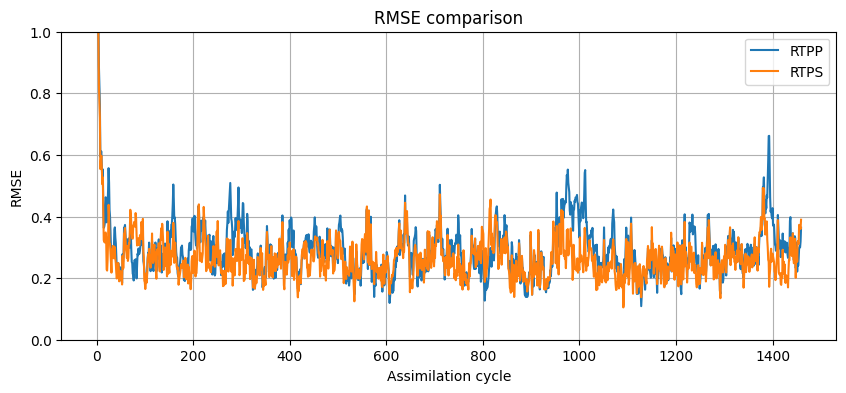

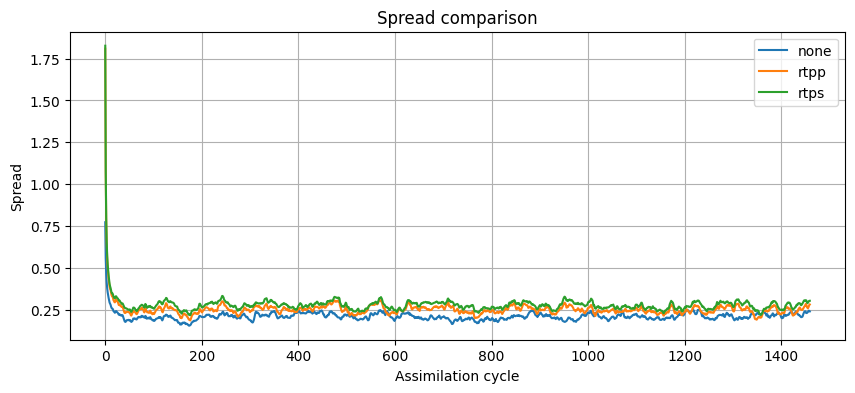

In [4]:
# =====================================================================
# 5. RMSEとSpreadの比較プロット
# =====================================================================
plt.figure(figsize=(10, 4))

plt.plot(results["rtpp"]["rmse"], label="RTPP")
plt.plot(results["rtps"]["rmse"], label="RTPS")
plt.xlabel("Assimilation cycle")
plt.ylabel("RMSE")
plt.ylim(0, 1.0)
plt.title("RMSE comparison")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
for method in results:
    plt.plot(results[method]["spread"], label=method)
plt.xlabel("Assimilation cycle")
plt.ylabel("Spread")
plt.title("Spread comparison")
plt.legend()
plt.grid(True)
plt.show()


## $\alpha$ sensitivity

In [5]:
# =====================================================================
# Fast alpha sensitivity experiment using joblib
# None / RTPP / RTPS 比較
# =====================================================================

import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
import time

# ------------------------------------------------------------
# 1. 実験設定
# ------------------------------------------------------------
num_eval_cycles = num_cycles       # まずは短め。全期間で回すなら num_cycles に変更
spinup = int(num_cycles * 0.1)                # 平均計算から除外する初期サイクル数

sigma = 4.0                 # 局所化半径
inflation = 1.00            # 乗算的インフレーション Delta
obs_indices = np.arange(N)  # 全点観測

alpha_list = np.arange(0.0, 1.01, 0.05)  # RTPP/RTPS の alpha 値のリスト

seed = 42                   # 全実験で同じ初期アンサンブルにする
n_jobs = -1                 # -1 で全CPUコア使用。重い場合は 2, 4 などに変更

# ------------------------------------------------------------
# 2. 1ケース分の実行関数
# ------------------------------------------------------------
def run_one_alpha_case(method, alpha):
    """
    method: "none", "rtpp", "rtps"
    alpha : RTPP/RTPS の relaxation coefficient
    """
    start = time.time()

    rmse, spread = run_letkf_experiment(
        y_o_data=y_o_data_full[:num_eval_cycles],
        true_states=true_states[:num_eval_cycles],
        obs_indices=obs_indices,
        sigma=sigma,
        inflation=inflation,
        method=method,
        alpha=alpha,
        seed=seed,
    )

    mean_rmse = np.mean(rmse[spinup:])
    mean_spread = np.mean(spread[spinup:])
    spread_rmse_ratio = mean_spread / (mean_rmse + 1.0e-12)

    elapsed = time.time() - start

    return {
        "method": method,
        "alpha": alpha,
        "rmse": rmse,
        "spread": spread,
        "mean_rmse": mean_rmse,
        "mean_spread": mean_spread,
        "spread_rmse_ratio": spread_rmse_ratio,
        "elapsed_sec": elapsed,
    }

# ------------------------------------------------------------
# 3. 実行ケース作成
# ------------------------------------------------------------
cases = []

# None = LETKF-mult は alpha に依存しないので1回だけ
cases.append(("none", 0.0))

# RTPP / RTPS は alpha を振る
for alpha in alpha_list:
    cases.append(("rtpp", float(alpha)))
    cases.append(("rtps", float(alpha)))

print("Number of experiments:", len(cases))
print("Cases:")
for c in cases:
    print(c)

# ------------------------------------------------------------
# 4. joblib で並列実行
# ------------------------------------------------------------
t0 = time.time()

results_list = Parallel(
    n_jobs=n_jobs,
    backend="loky",
    verbose=10
)(
    delayed(run_one_alpha_case)(method, alpha)
    for method, alpha in cases
)

total_elapsed = time.time() - t0
print(f"All experiments finished. Total elapsed time: {total_elapsed:.2f} sec")

# ------------------------------------------------------------
# 5. 結果を整理
# ------------------------------------------------------------
alpha_results = {
    "none": {},
    "rtpp": {},
    "rtps": {},
}

summary = []

for res in results_list:
    method = res["method"]
    alpha = res["alpha"]

    if method == "none":
        alpha_results["none"]["rmse"] = res["rmse"]
        alpha_results["none"]["spread"] = res["spread"]
    else:
        alpha_results[method][alpha] = {
            "rmse": res["rmse"],
            "spread": res["spread"],
        }

    summary.append({
        "method": method,
        "alpha": alpha,
        "mean_rmse": res["mean_rmse"],
        "mean_spread": res["mean_spread"],
        "spread_rmse_ratio": res["spread_rmse_ratio"],
        "elapsed_sec": res["elapsed_sec"],
    })

# 表示用に method, alpha でソート
summary = sorted(summary, key=lambda x: (x["method"], x["alpha"]))

try:
    import pandas as pd
    summary_df = pd.DataFrame(summary)
    display(summary_df)
except Exception:
    for row in summary:
        print(row)

# ------------------------------------------------------------
# 6. None / LETKF-mult の基準値
# ------------------------------------------------------------
none_row = [row for row in summary if row["method"] == "none"][0]

mean_rmse_none = none_row["mean_rmse"]
mean_spread_none = none_row["mean_spread"]
mean_ratio_none = none_row["spread_rmse_ratio"]

rmse_none = alpha_results["none"]["rmse"]
spread_none = alpha_results["none"]["spread"]

print()
print("Baseline: None / LETKF-mult")
print(f"mean RMSE       = {mean_rmse_none:.6f}")
print(f"mean spread     = {mean_spread_none:.6f}")
print(f"spread/RMSE     = {mean_ratio_none:.6f}")



Number of experiments: 43
Cases:
('none', 0.0)
('rtpp', 0.0)
('rtps', 0.0)
('rtpp', 0.05)
('rtps', 0.05)
('rtpp', 0.1)
('rtps', 0.1)
('rtpp', 0.15000000000000002)
('rtps', 0.15000000000000002)
('rtpp', 0.2)
('rtps', 0.2)
('rtpp', 0.25)
('rtps', 0.25)
('rtpp', 0.30000000000000004)
('rtps', 0.30000000000000004)
('rtpp', 0.35000000000000003)
('rtps', 0.35000000000000003)
('rtpp', 0.4)
('rtps', 0.4)
('rtpp', 0.45)
('rtps', 0.45)
('rtpp', 0.5)
('rtps', 0.5)
('rtpp', 0.55)
('rtps', 0.55)
('rtpp', 0.6000000000000001)
('rtps', 0.6000000000000001)
('rtpp', 0.65)
('rtps', 0.65)
('rtpp', 0.7000000000000001)
('rtps', 0.7000000000000001)
('rtpp', 0.75)
('rtps', 0.75)
('rtpp', 0.8)
('rtps', 0.8)
('rtpp', 0.8500000000000001)
('rtps', 0.8500000000000001)
('rtpp', 0.9)
('rtps', 0.9)
('rtpp', 0.9500000000000001)
('rtps', 0.9500000000000001)
('rtpp', 1.0)
('rtps', 1.0)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:   39.5s
[Parallel(n_jobs=-1)]: Done  17 out of  43 | elapsed:  1.2min remaining:  1.8min
[Parallel(n_jobs=-1)]: Done  22 out of  43 | elapsed:  1.3min remaining:  1.2min
[Parallel(n_jobs=-1)]: Done  27 out of  43 | elapsed:  1.3min remaining:   47.6s
[Parallel(n_jobs=-1)]: Done  32 out of  43 | elapsed:  1.5min remaining:   30.7s
[Parallel(n_jobs=-1)]: Done  37 out of  43 | elapsed:  1.8min remaining:   17.5s
[Parallel(n_jobs=-1)]: Done  43 out of  43 | elapsed:  1.9min finished


All experiments finished. Total elapsed time: 111.82 sec


,method,alpha,mean_rmse,mean_spread,spread_rmse_ratio,elapsed_sec
0,none,0.00,4.709988,0.198018,0.042042,33.514955
1,rtpp,0.00,4.709988,0.198018,0.042042,34.767965
2,rtpp,0.05,4.671650,0.209156,0.044771,42.521200
3,rtpp,0.10,4.391683,0.207462,0.047240,39.066069
4,rtpp,0.15,4.354903,0.218675,0.050213,34.176559
5,rtpp,0.20,3.941457,0.227279,0.057664,40.015592
6,rtpp,0.25,3.582262,0.238735,0.066644,34.302417
7,rtpp,0.30,0.328223,0.233999,0.712926,36.492592
8,rtpp,0.35,0.394554,0.247540,0.627393,35.380945
9,rtpp,0.40,0.267541,0.262175,0.979946,37.216686



Baseline: None / LETKF-mult
mean RMSE       = 4.709988
mean spread     = 0.198018
spread/RMSE     = 0.042042


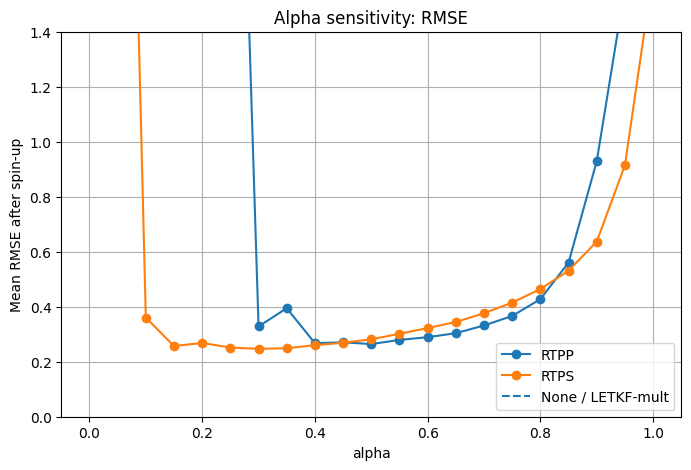

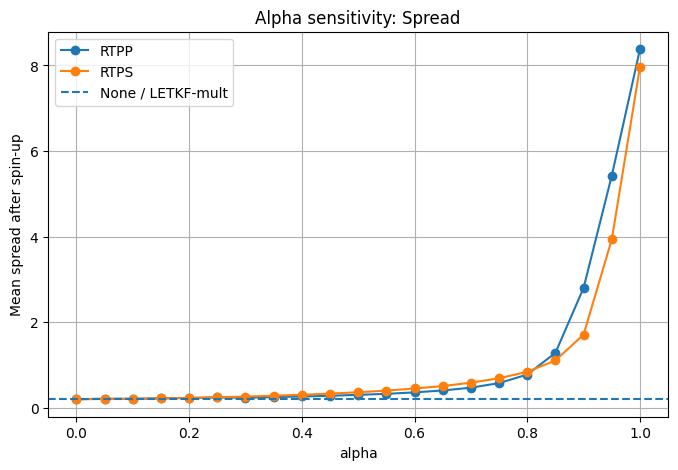

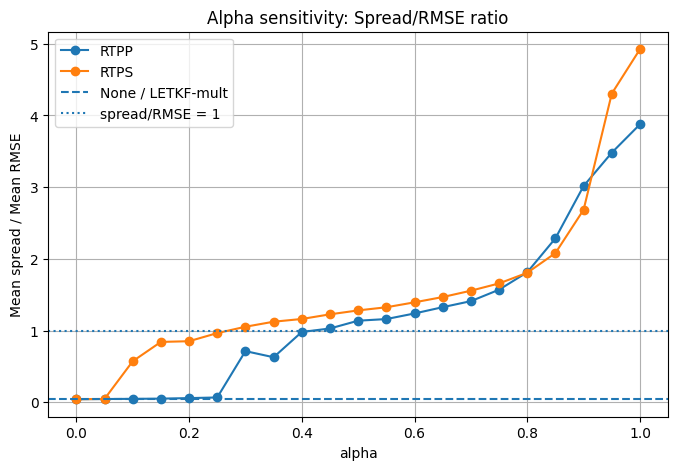


Best alpha for RTPP by mean RMSE: 0.5
Best alpha for RTPS by mean RMSE: 0.30000000000000004


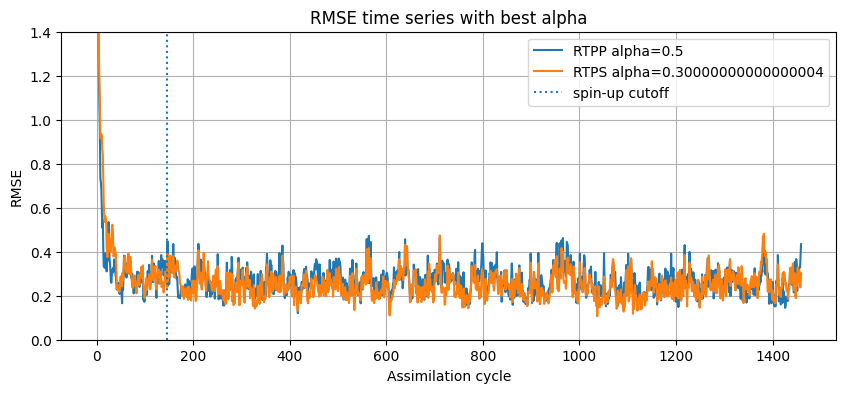

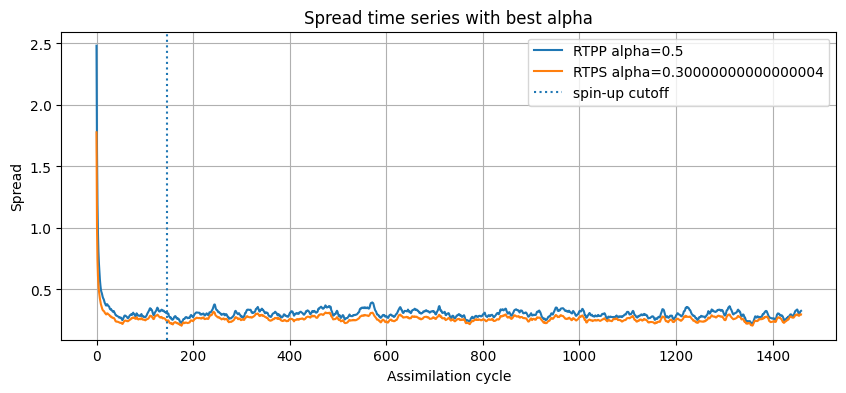


Alpha sensitivity summary
--------------------------------
None / LETKF-mult: RMSE = 4.709988, spread = 0.198018
Best RTPP alpha  : 0.5, RMSE = 0.264210
Best RTPS alpha  : 0.30000000000000004, RMSE = 0.247028


In [6]:
# ------------------------------------------------------------
# 7. alpha ごとの平均RMSE / spread / spread-RMSE比
# ------------------------------------------------------------
rtpp_mean_rmse = np.array([
    np.mean(alpha_results["rtpp"][float(alpha)]["rmse"][spinup:])
    for alpha in alpha_list
])

rtps_mean_rmse = np.array([
    np.mean(alpha_results["rtps"][float(alpha)]["rmse"][spinup:])
    for alpha in alpha_list
])

rtpp_mean_spread = np.array([
    np.mean(alpha_results["rtpp"][float(alpha)]["spread"][spinup:])
    for alpha in alpha_list
])

rtps_mean_spread = np.array([
    np.mean(alpha_results["rtps"][float(alpha)]["spread"][spinup:])
    for alpha in alpha_list
])

rtpp_ratio = rtpp_mean_spread / (rtpp_mean_rmse + 1.0e-12)
rtps_ratio = rtps_mean_spread / (rtps_mean_rmse + 1.0e-12)

# ------------------------------------------------------------
# 8. alpha に対する平均RMSE
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(alpha_list, rtpp_mean_rmse, marker="o", label="RTPP")
plt.plot(alpha_list, rtps_mean_rmse, marker="o", label="RTPS")
plt.axhline(mean_rmse_none, linestyle="--", label="None / LETKF-mult")
plt.xlabel("alpha")
plt.ylabel("Mean RMSE after spin-up")
plt.ylim(0, 1.4)
plt.title("Alpha sensitivity: RMSE")
plt.grid(True)
plt.legend()
plt.show()

# ------------------------------------------------------------
# 9. alpha に対する平均spread
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(alpha_list, rtpp_mean_spread, marker="o", label="RTPP")
plt.plot(alpha_list, rtps_mean_spread, marker="o", label="RTPS")
plt.axhline(mean_spread_none, linestyle="--", label="None / LETKF-mult")
plt.xlabel("alpha")
plt.ylabel("Mean spread after spin-up")
plt.title("Alpha sensitivity: Spread")
plt.grid(True)
plt.legend()
plt.show()

# ------------------------------------------------------------
# 10. alpha に対する spread/RMSE 比
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(alpha_list, rtpp_ratio, marker="o", label="RTPP")
plt.plot(alpha_list, rtps_ratio, marker="o", label="RTPS")
plt.axhline(mean_ratio_none, linestyle="--", label="None / LETKF-mult")
plt.axhline(1.0, linestyle=":", label="spread/RMSE = 1")
plt.xlabel("alpha")
plt.ylabel("Mean spread / Mean RMSE")
plt.title("Alpha sensitivity: Spread/RMSE ratio")
plt.grid(True)
plt.legend()
plt.show()

# ------------------------------------------------------------
# 11. 最良 alpha を選んで時系列比較
# ------------------------------------------------------------
best_alpha_rtpp = float(alpha_list[np.nanargmin(rtpp_mean_rmse)])
best_alpha_rtps = float(alpha_list[np.nanargmin(rtps_mean_rmse)])

print()
print(f"Best alpha for RTPP by mean RMSE: {best_alpha_rtpp}")
print(f"Best alpha for RTPS by mean RMSE: {best_alpha_rtps}")

rmse_rtpp_best = alpha_results["rtpp"][best_alpha_rtpp]["rmse"]
rmse_rtps_best = alpha_results["rtps"][best_alpha_rtps]["rmse"]

spread_rtpp_best = alpha_results["rtpp"][best_alpha_rtpp]["spread"]
spread_rtps_best = alpha_results["rtps"][best_alpha_rtps]["spread"]

plt.figure(figsize=(10, 4))
plt.plot(rmse_rtpp_best, label=f"RTPP alpha={best_alpha_rtpp}")
plt.plot(rmse_rtps_best, label=f"RTPS alpha={best_alpha_rtps}")
plt.axvline(spinup, linestyle=":", label="spin-up cutoff")
plt.xlabel("Assimilation cycle")
plt.ylabel("RMSE")
plt.ylim(0, 1.4)
plt.title("RMSE time series with best alpha")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(spread_rtpp_best, label=f"RTPP alpha={best_alpha_rtpp}")
plt.plot(spread_rtps_best, label=f"RTPS alpha={best_alpha_rtps}")
plt.axvline(spinup, linestyle=":", label="spin-up cutoff")
plt.xlabel("Assimilation cycle")
plt.ylabel("Spread")
plt.title("Spread time series with best alpha")
plt.grid(True)
plt.legend()
plt.show()

# ------------------------------------------------------------
# 12. 最終確認表示
# ------------------------------------------------------------
print()
print("Alpha sensitivity summary")
print("--------------------------------")
print(f"None / LETKF-mult: RMSE = {mean_rmse_none:.6f}, spread = {mean_spread_none:.6f}")
print(f"Best RTPP alpha  : {best_alpha_rtpp}, RMSE = {np.nanmin(rtpp_mean_rmse):.6f}")
print(f"Best RTPS alpha  : {best_alpha_rtps}, RMSE = {np.nanmin(rtps_mean_rmse):.6f}")

## sigma × delta × alpha 3D heatmap experiment

Observation: all points
num_eval_cycles: 1460
spinup: 146
sigma_list: [2. 3. 4. 5.]
delta_list: [1.   1.02 1.03 1.04 1.05 1.1 ]
alpha_list: [0.]
methods: ['rtpp', 'rtps']
Number of experiments: 48


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:   34.8s
[Parallel(n_jobs=-1)]: Done  22 out of  48 | elapsed:  1.2min remaining:  1.4min
[Parallel(n_jobs=-1)]: Done  27 out of  48 | elapsed:  1.2min remaining:   57.8s
[Parallel(n_jobs=-1)]: Done  32 out of  48 | elapsed:  1.4min remaining:   40.7s
[Parallel(n_jobs=-1)]: Done  37 out of  48 | elapsed:  1.8min remaining:   32.4s
[Parallel(n_jobs=-1)]: Done  42 out of  48 | elapsed:  1.9min remaining:   16.1s


All grid experiments finished. Total elapsed time: 119.47 sec


[Parallel(n_jobs=-1)]: Done  48 out of  48 | elapsed:  2.0min finished


,method,sigma,delta,alpha,mean_rmse,mean_spread,spread_rmse_ratio,elapsed_sec
17,rtpp,4.0,1.10,0.0,0.245518,0.253887,1.034090,35.860144
10,rtpp,3.0,1.05,0.0,0.249669,0.237273,0.950351,38.838546
11,rtpp,3.0,1.10,0.0,0.255417,0.270557,1.059277,33.574853
8,rtpp,3.0,1.03,0.0,0.267010,0.222180,0.832103,33.619974
9,rtpp,3.0,1.04,0.0,0.274474,0.229565,0.836382,32.592153
5,rtpp,2.0,1.10,0.0,0.278231,0.296563,1.065886,31.653429
4,rtpp,2.0,1.05,0.0,0.280422,0.260533,0.929075,38.855837
3,rtpp,2.0,1.04,0.0,0.284365,0.252444,0.887746,39.847234
2,rtpp,2.0,1.03,0.0,0.298135,0.245018,0.821835,40.415992
1,rtpp,2.0,1.02,0.0,0.333404,0.236814,0.710291,32.092389


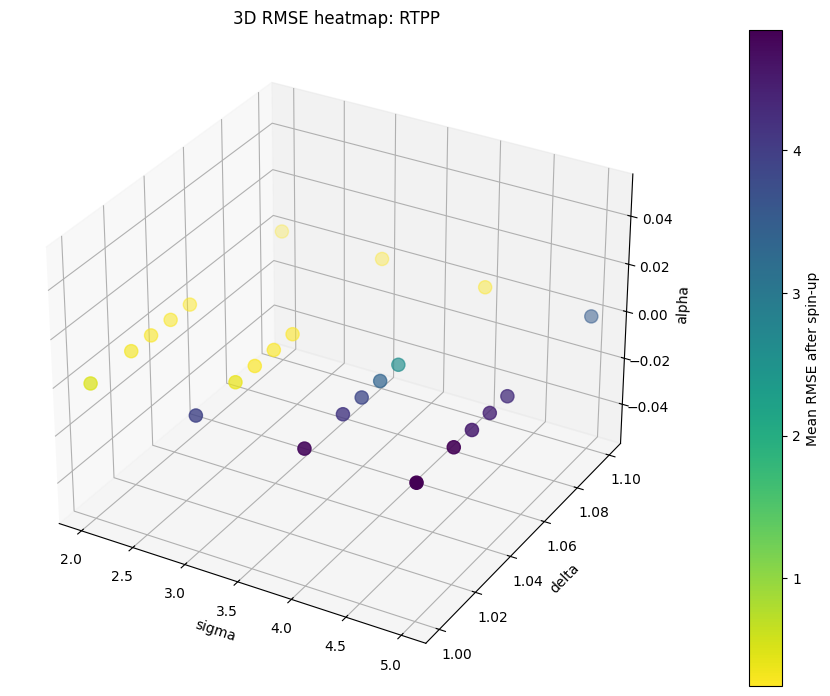

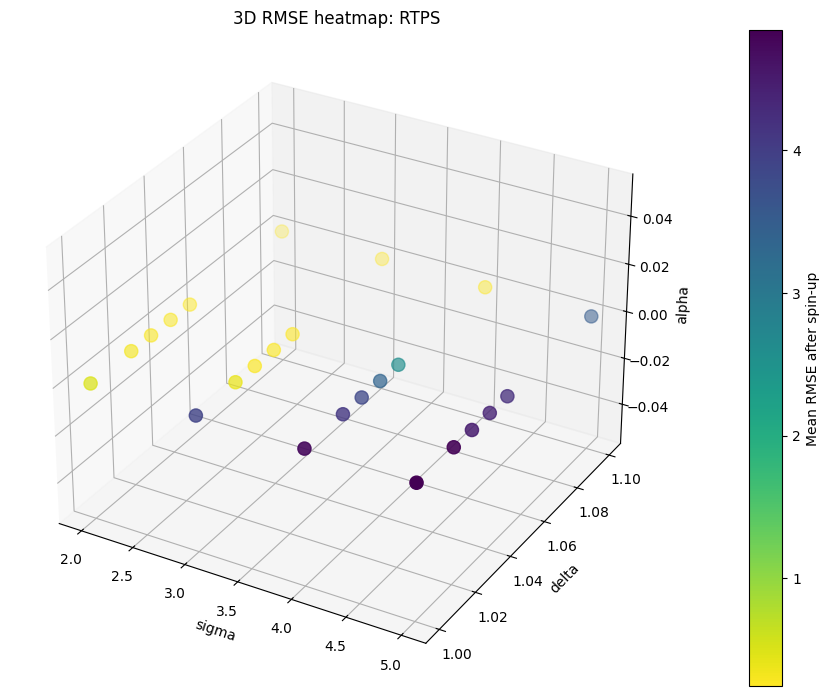

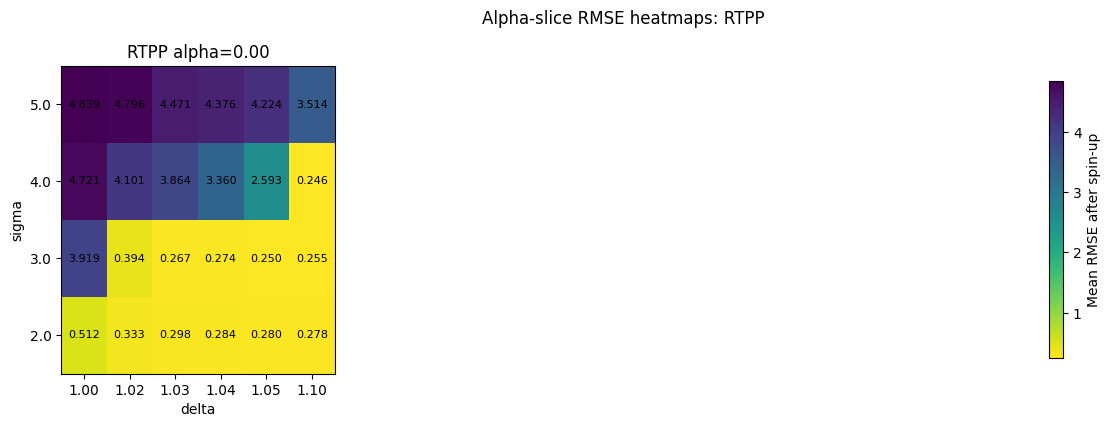

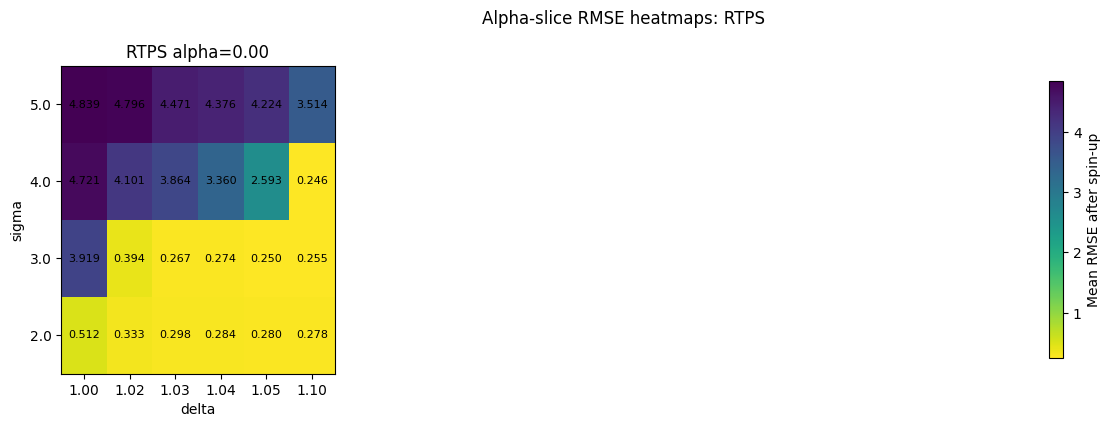


Best parameters for RTPP
--------------------------------
sigma      = 4.0
delta      = 1.1
alpha      = 0.0
mean RMSE  = 0.245518
mean spread= 0.253887
spread/RMSE= 1.034090

Best parameters for RTPS
--------------------------------
sigma      = 4.0
delta      = 1.1
alpha      = 0.0
mean RMSE  = 0.245518
mean spread= 0.253887
spread/RMSE= 1.034090


In [10]:
# =====================================================================
# 3D hyperparameter heatmap: sigma × delta × alpha
# 全点観測 / RTPP・RTPSのみ / Noneなし
# =====================================================================

import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
import time

# ------------------------------------------------------------
# 1. 実験設定
# ------------------------------------------------------------
# 全点観測
obs_indices_all = np.arange(N)

# 計算量がかなり大きくなるので、最初は短め推奨。
# 本番で全期間を使うなら num_eval_cycles = num_cycles に変更。
num_eval_cycles = num_cycles
spinup = int(num_eval_cycles * 0.1)

# sigma: 局所化半径
sigma_list = np.array([2.0, 3.0, 4.0, 5.0])

# delta: multiplicative inflation coefficient
# コード内では inflation として渡す。
delta_list = np.array([1.00, 1.02, 1.03, 1.04, 1.05, 1.10])

# alpha: RTPP / RTPS coefficient
alpha_list_grid = np.array([0.0])

methods_grid = ["rtpp", "rtps"]

seed = 810
n_jobs = -1

print("Observation: all points")
print("num_eval_cycles:", num_eval_cycles)
print("spinup:", spinup)
print("sigma_list:", sigma_list)
print("delta_list:", delta_list)
print("alpha_list:", alpha_list_grid)
print("methods:", methods_grid)

# ------------------------------------------------------------
# 2. 1ケース分の実行関数
# ------------------------------------------------------------
def run_one_sigma_delta_alpha_case(method, sigma, delta, alpha):
    start = time.time()

    rmse, spread = run_letkf_experiment(
        y_o_data=y_o_data_full[:num_eval_cycles],
        true_states=true_states[:num_eval_cycles],
        obs_indices=obs_indices_all,
        sigma=float(sigma),
        inflation=float(delta),
        method=method,
        alpha=float(alpha),
        seed=seed,
    )

    mean_rmse = np.nanmean(rmse[spinup:])
    mean_spread = np.nanmean(spread[spinup:])
    spread_rmse_ratio = mean_spread / (mean_rmse + 1.0e-12)

    elapsed = time.time() - start

    return {
        "method": method,
        "sigma": float(sigma),
        "delta": float(delta),
        "alpha": float(alpha),
        "rmse": rmse,
        "spread": spread,
        "mean_rmse": mean_rmse,
        "mean_spread": mean_spread,
        "spread_rmse_ratio": spread_rmse_ratio,
        "elapsed_sec": elapsed,
    }

# ------------------------------------------------------------
# 3. 実行ケース作成
# ------------------------------------------------------------
grid_cases = []

for method in methods_grid:
    for sigma in sigma_list:
        for delta in delta_list:
            for alpha in alpha_list_grid:
                grid_cases.append((method, sigma, delta, alpha))

print("Number of experiments:", len(grid_cases))

# ------------------------------------------------------------
# 4. joblibで並列実行
# ------------------------------------------------------------
t0 = time.time()

grid_results_list = Parallel(
    n_jobs=n_jobs,
    backend="loky",
    verbose=10,
)(
    delayed(run_one_sigma_delta_alpha_case)(method, sigma, delta, alpha)
    for method, sigma, delta, alpha in grid_cases
)

total_elapsed = time.time() - t0
print(f"All grid experiments finished. Total elapsed time: {total_elapsed:.2f} sec")

# ------------------------------------------------------------
# 5. 結果をDataFrame化
# ------------------------------------------------------------
try:
    import pandas as pd

    grid_summary_df = pd.DataFrame([
        {
            "method": r["method"],
            "sigma": r["sigma"],
            "delta": r["delta"],
            "alpha": r["alpha"],
            "mean_rmSE": r["mean_rmse"],
            "mean_spread": r["mean_spread"],
            "spread_rmse_ratio": r["spread_rmse_ratio"],
            "elapsed_sec": r["elapsed_sec"],
        }
        for r in grid_results_list
    ])

    # 列名の typo を避けるため補正
    grid_summary_df = grid_summary_df.rename(columns={"mean_rmSE": "mean_rmse"})

    display(grid_summary_df.sort_values(["method", "mean_rmse"]).head(20))

except Exception:
    grid_summary_df = None
    for r in sorted(grid_results_list, key=lambda x: (x["method"], x["mean_rmse"]))[:20]:
        print(
            r["method"],
            "sigma=", r["sigma"],
            "delta=", r["delta"],
            "alpha=", r["alpha"],
            "mean_rmse=", r["mean_rmse"],
        )

# ------------------------------------------------------------
# 6. 結果アクセス用の辞書
# ------------------------------------------------------------
grid_results = {}

for r in grid_results_list:
    key = (
        r["method"],
        float(r["sigma"]),
        float(r["delta"]),
        float(r["alpha"]),
    )
    grid_results[key] = r

# ------------------------------------------------------------
# 7. 3D heatmap風 scatter
#    x=sigma, y=delta, z=alpha, color=mean RMSE
# ------------------------------------------------------------
def plot_3d_rmse_heatmap(method):
    data = [r for r in grid_results_list if r["method"] == method]

    xs = np.array([r["sigma"] for r in data])
    ys = np.array([r["delta"] for r in data])
    zs = np.array([r["alpha"] for r in data])
    cs = np.array([r["mean_rmse"] for r in data])

    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection="3d")

    sc = ax.scatter(
        xs,
        ys,
        zs,
        c=cs,
        cmap="viridis_r",
        s=90,
        depthshade=True,
    )

    ax.set_xlabel("sigma")
    ax.set_ylabel("delta")
    ax.set_zlabel("alpha")
    ax.set_title(f"3D RMSE heatmap: {method.upper()}")

    cbar = fig.colorbar(sc, ax=ax, pad=0.1)
    cbar.set_label("Mean RMSE after spin-up")

    plt.tight_layout()
    plt.show()

plot_3d_rmse_heatmap("rtpp")
plot_3d_rmse_heatmap("rtps")

# ------------------------------------------------------------
# 8. alphaごとの2D heatmap slice
#    各alphaで sigma × delta のRMSEヒートマップを表示
# ------------------------------------------------------------
def build_rmse_matrix(method, alpha):
    """
    rows: sigma
    cols: delta
    values: mean RMSE
    """
    Z = np.full((len(sigma_list), len(delta_list)), np.nan)

    for i, sigma in enumerate(sigma_list):
        for j, delta in enumerate(delta_list):
            key = (method, float(sigma), float(delta), float(alpha))
            if key in grid_results:
                Z[i, j] = grid_results[key]["mean_rmse"]

    return Z

def plot_alpha_slice_heatmaps(method):
    n_alpha = len(alpha_list_grid)
    ncols = 3
    nrows = int(np.ceil(n_alpha / ncols))

    # method内で色範囲を統一
    all_values = []
    for alpha in alpha_list_grid:
        Z = build_rmse_matrix(method, float(alpha))
        all_values.append(Z.ravel())
    all_values = np.concatenate(all_values)

    vmin = np.nanmin(all_values)
    vmax = np.nanmax(all_values)

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), squeeze=False)

    for idx, alpha in enumerate(alpha_list_grid):
        row = idx // ncols
        col = idx % ncols
        ax = axes[row][col]

        Z = build_rmse_matrix(method, float(alpha))

        im = ax.imshow(
            Z,
            origin="lower",
            aspect="auto",
            cmap="viridis_r",
            vmin=vmin,
            vmax=vmax,
        )

        ax.set_title(f"{method.upper()} alpha={alpha:.2f}")
        ax.set_xlabel("delta")
        ax.set_ylabel("sigma")

        ax.set_xticks(np.arange(len(delta_list)))
        ax.set_xticklabels([f"{d:.2f}" for d in delta_list])

        ax.set_yticks(np.arange(len(sigma_list)))
        ax.set_yticklabels([f"{s:.1f}" for s in sigma_list])

        # セル内にRMSE値を書く
        for i in range(len(sigma_list)):
            for j in range(len(delta_list)):
                val = Z[i, j]
                if np.isfinite(val):
                    ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=8)

    # 余ったsubplotを消す
    for idx in range(n_alpha, nrows * ncols):
        row = idx // ncols
        col = idx % ncols
        axes[row][col].axis("off")

    fig.suptitle(f"Alpha-slice RMSE heatmaps: {method.upper()}", y=1.02)

    cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.9)
    cbar.set_label("Mean RMSE after spin-up")

    plt.show()

plot_alpha_slice_heatmaps("rtpp")
plot_alpha_slice_heatmaps("rtps")

# ------------------------------------------------------------
# 9. 最良パラメータ表示
# ------------------------------------------------------------
def print_best_params(method):
    data = [r for r in grid_results_list if r["method"] == method]
    best = min(data, key=lambda r: r["mean_rmse"])

    print()
    print(f"Best parameters for {method.upper()}")
    print("--------------------------------")
    print(f"sigma      = {best['sigma']}")
    print(f"delta      = {best['delta']}")
    print(f"alpha      = {best['alpha']}")
    print(f"mean RMSE  = {best['mean_rmse']:.6f}")
    print(f"mean spread= {best['mean_spread']:.6f}")
    print(f"spread/RMSE= {best['spread_rmse_ratio']:.6f}")

print_best_params("rtpp")
print_best_params("rtps")